# Summary statistics for the comments dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

from database.comments import Comments

There are two datasets loaded here - the dataset of all planning applciation IDs for 2021 onwards across the 8 relevant london councils. Plus the comments dataset - which is the free-text comments we've been able to scrape from the council websites. 

In [2]:
# Application dataset 
application_df_path = "/Users/bea/Documents/AI4CI/projects/comment_summariser/comment_summariser/data/PLD_application_ids/all_since21_cleaned.csv"
application_df = pd.read_csv(application_df_path)
print(f"There are {len(application_df)} applications in the dataset.")

There are 5850 applications in the dataset.


In [3]:
# drop 'Bromley' applications -  sicne haven't been able to get the comments for these
application_df = application_df[application_df['borough'] != 'Bromley']
print(f"There are {len(application_df)} applications in the dataset after dropping Bromley applications.")

There are 5077 applications in the dataset after dropping Bromley applications.


In [4]:
application_df.groupby('borough').size()

borough
Barnet            1291
Brent              935
City Of London      21
Ealing            1122
Lambeth            483
Newham             424
Southwark          308
Westminster        493
dtype: int64

In [5]:
# Comments dataset
cs = Comments()
df = cs.read_all()
df.head()

Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,lon,cleaned_comment_text
0,76524,Southwark,24/AP/2325_38,24/AP/2325,None,Objects,2024-08-28,The public notices were displayed on 21st Augu...,2025-04-08,NaN,NaN,The public notices were displayed on 21st Augu...
1,89327,Ealing,223281FUL_4,223281FUL,36 First Avenue East Acton LONDON W3 7JR W3 7JR,Objects,2022-08-09,The owner of 1 Old Oak Road has submitted a pr...,2025-04-10,51.507800,-0.246690,The owner of 1 Old has submitted a previous ap...
2,75648,Westminster,21/08160/COOUT_15,21/08160/COOUT,None,Objects,2022-01-18,I would like to make an objection to these pro...,2025-04-07,NaN,NaN,I would like to make an objection to these pro...
3,77304,Ealing,214277FUL_11,214277FUL,179 Clitherow Avenue London W7 2BU W7 2BU,Objects,2021-08-03,"As a Clitherow Avenue resident, I am extremely...",2025-04-08,51.497836,-0.324786,"As a resident, I am extremely unhappy with the..."
4,77303,Ealing,214277FUL_10,214277FUL,167 clitherow avenue ealing london W7 2BU W7 2BU,Objects,2021-08-03,I object to this development being allowed to ...,2025-04-08,51.497836,-0.324786,I object to this development being allowed to ...


In [6]:
# format 'council' column so 'City of London' not 'City Of London'
df['council'].replace('City Of London', 'City of London', inplace=True)

print(f"The councils in the dataset are: {df['council'].unique()}")

The councils in the dataset are: ['Southwark' 'Ealing' 'Westminster' 'Lambeth' 'Barnet' 'Brent' 'Newham'
 'City of London']


/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_9758/3217002554.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['council'].replace('City Of London', 'City of London', inplace=True)


In [7]:
print(f"Total number of comments: {len(df)}")
print(f"Total number of applications (with comments scraped): {len(df.application_id.unique())}")

Total number of comments: 30393
Total number of applications (with comments scraped): 2453


In [8]:
application_df

,lpa_app_no,valid_date,decision_date,borough,application_details.residential_details.total_no_proposed_residential_units,application_details.residential_details.total_no_affordable_units,application_details.residential_details.site_area,application_details.residential_details.habitable_rooms_density,pp_id,uprn,status,decision,street_name,site_name,site_number,polygon,wgs84_polygon,description
0,24/02204/FUL,2024-11-19 00:00:00,2025-03-25 00:00:00,Newham,1,NaN,NaN,NaN,PP-12728004,1.002400e+10,Approved,Approved,Falmouth Street,NaN,"2, 10",GEOMETRYCOLLECTION (POLYGON ((538894.0 185094....,"polygon=linearring(x=[0.001716, 0.001703, 0.00...",Proposed mansard roof extension to the main bu...
1,25/0089,2025-01-27 00:00:00,2025-03-24 00:00:00,Brent,1,NaN,NaN,NaN,PP-13670128,2.022052e+08,Approved,Approved,NaN,"92 Blenheim Gardens, London, NW2 4NT",NaN,NaN,NaN,Proposed change of use from HMO to a single dw...
2,24/1783,2024-08-05 00:00:00,2025-03-24 00:00:00,Brent,9,NaN,NaN,NaN,PP-12267268,2.021029e+08,Refused,Refused,NaN,"1 - 6 The Drive, London, NW10 3UB",NaN,NaN,NaN,Demolition of existing buildings and garages a...
3,25/00205/PRECOU,2025-02-03 00:00:00,2025-03-25 00:00:00,Newham,2,NaN,NaN,NaN,PP-13735437,1.000900e+10,NaN,Refused,Forest Lane,NaN,"176, 177",GEOMETRYCOLLECTION (POLYGON ((540475.0 185388....,"polygon=linearring(x=[0.024619, 0.024663, 0.02...",Prior Approval application for the change of u...
4,25/00181/PRECOU,2025-01-30 00:00:00,2025-03-26 00:00:00,Newham,1,NaN,NaN,NaN,PP-13687528,1.009348e+10,NaN,Refused,Sprowston Mews,NaN,66,GEOMETRYCOLLECTION (POLYGON ((540218.0 185015....,"polygon=linearring(x=[0.020766, 0.020563, 0.02...",Prior Approval application for the change of u...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5843,23/3665,2023-11-22 00:00:00,2024-02-08 00:00:00,Brent,1,NaN,NaN,NaN,PP-12623129,2.020331e+08,Approved,Approved,NaN,"68 Watford Road, Wembley, HA0 3ES",NaN,"polygon=linearring(x=[516710.0, 516717.1, 5167...",NaN,Change of use from dwellinghouse to large 9 pe...
5844,22/03810/FUL,2022-10-31 00:00:00,2024-12-19 00:00:00,Lambeth,1,NaN,NaN,NaN,PP-11628675,1.009496e+10,Approved,Approved,Development Control Pseudo Street,Garages To The Rear Of 40 And 42 Gracefield Ga...,NaN,GEOMETRYCOLLECTION (POLYGON ((530362.15 172026...,"polygon=linearring(x=[-0.12605149999999998, -0...",Erection of 1 single storey dwellinghouse (Use...
5845,23/02837/FUL,2023-09-05 00:00:00,2024-10-21 00:00:00,Lambeth,2,NaN,NaN,NaN,PP-12426853,1.000219e+11,Approved,Approved,NaN,17 Tarrington Close,NaN,NaN,NaN,NaN
5846,23/1057,2023-04-06 00:00:00,2023-06-01 00:00:00,Brent,4,NaN,NaN,NaN,PP-12056911,2.020633e+08,Refused,Refused,NaN,"57 Northwick Avenue, Harrow, HA3 0AU",NaN,"polygon=linearring(x=[516747.65, 516732.3, 516...",NaN,Proposed conversion of dwellinghouse to 4x sel...


In [9]:
# mean number of comments per application accoutning for applications with no comments
mean_comments_per_application = len(df) / len(application_df.pp_id.unique())
print(f"Mean number of comments per application: {mean_comments_per_application:.2f}")

Mean number of comments per application: 6.06


In [10]:
apps_with_no_comments = len(application_df.pp_id.unique()) - len(df.application_id.unique())
print(f"Number of applications with no comments: {apps_with_no_comments}")
print(f"Number of applications with comments: {len(df.application_id.unique())}")

# median number of comments per application accoutning for applications with no comments
# Create a DataFrame with all applications and their comment counts
comment_counts = df.groupby('application_id').size().reset_index(name='comment_count')
# Merge with the application DataFrame to include all applications
application_counts = application_df[['pp_id']].rename(columns={'pp_id': 'application_id'})
merged_counts = comment_counts.merge(application_counts, on='application_id', how='left').fillna(0)
# Calculate the median of comment counts
median_comments_per_application = merged_counts['comment_count'].median()
print(f"Median number of comments per application: {median_comments_per_application:.2f}")                                                        

Number of applications with no comments: 2566
Number of applications with comments: 2453
Median number of comments per application: 3.00


/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_9758/3587541661.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


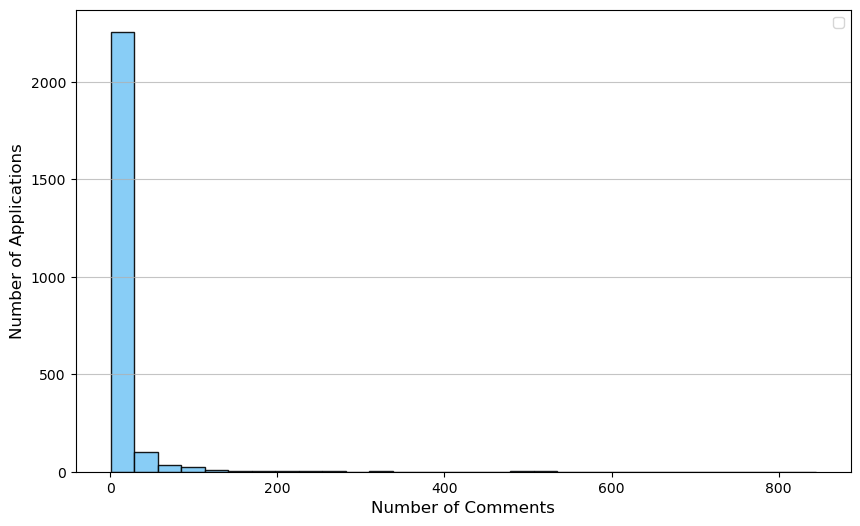

In [11]:
# plot histogram of merged_counts['comment_count']
plt.figure(figsize=(10, 6))
plt.hist(merged_counts['comment_count'], bins=30, edgecolor='black', alpha=0.9, color='xkcd:lightblue')
# plt.title('Distribution of Comments per Application')
plt.xlabel('Number of Comments', fontsize=12)
plt.ylabel('Number of Applications', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.legend()
plt.show()

In [12]:
df.groupby("application_id").size().describe()

count    2453.000000
mean       12.390135
std        42.732741
min         1.000000
25%         1.000000
50%         3.000000
75%         8.000000
max       844.000000
dtype: float64

In [13]:
# groupby application_id and stance
df_grouped = df.groupby(["application_id", "stance"]).size().reset_index(name='count')

df_grouped.head()

,application_id,stance,count
0,164280FUL,Neutral,1
1,164280FUL,Objects,9
2,164280FUL,Supports,2
3,166503FUL,Objects,18
4,17/04202/FULL,Neutral,1


In [14]:
# Total count per application
total_counts = df_grouped.groupby('application_id')['count'].sum().rename('total')

# Count per stance per application
object_counts = df_grouped[df_grouped['stance'] == 'Objects'].groupby('application_id')['count'].sum().rename('objects')
support_counts = df_grouped[df_grouped['stance'] == 'Supports'].groupby('application_id')['count'].sum().rename('supports')
neutral_counts = df_grouped[df_grouped['stance'] == 'Neutral'].groupby('application_id')['count'].sum().rename('neutral')

# Combine all above together
summary = pd.concat([total_counts, object_counts, support_counts, neutral_counts], axis=1).fillna(0)

# Compute percentages
summary['object_percent'] = (summary['objects'] / summary['total']) * 100
summary['support_percent'] = (summary['supports'] / summary['total']) * 100
summary['neutral_percent'] = (summary['neutral'] / summary['total']) * 100

# Descriptive stats (mean)
mean_object_percent = summary['object_percent'].mean()
mean_support_percent = summary['support_percent'].mean()
mean_neutral_percent = summary['neutral_percent'].mean()

print(f"Mean % of objections per application: {mean_object_percent:.2f}%")
print(f"Mean % of supports per application: {mean_support_percent:.2f}%")
print(f"Mean % of neutrals per application: {mean_neutral_percent:.2f}%")


Mean % of objections per application: 80.05%
Mean % of supports per application: 9.01%
Mean % of neutrals per application: 10.95%


In [15]:
unique_app_counts = df.groupby('council')[['application_id', 'comment_id']].nunique().reset_index()

In [16]:
# Get number of unique applications and comments per council
unique_app_counts = df.groupby('council')[['application_id', 'comment_id']].nunique().reset_index()

# Rename for clarity
unique_app_counts.columns = ['council', 'no_applications_with_comments', 'total_comment_count']

# Compute mean number of comments per application
unique_app_counts['mean_comments_per_application'] = (
    unique_app_counts['total_comment_count'] / unique_app_counts['no_applications_with_comments']
)

unique_app_counts

,council,no_applications_with_comments,total_comment_count,mean_comments_per_application
0,Barnet,791,9172,11.595449
1,Brent,395,2419,6.124051
2,City of London,14,38,2.714286
3,Ealing,497,11592,23.323944
4,Lambeth,208,2587,12.437500
5,Newham,158,750,4.746835
6,Southwark,152,2488,16.368421
7,Westminster,238,1347,5.659664


In [17]:
df_council_count  = df[['council', 'stance']].groupby('council').value_counts().to_frame().reset_index()
df_council_count = df_council_count.pivot(index='council', columns='stance').reset_index()
df_council_count.columns = df_council_count.columns.droplevel(0)
df_council_count.columns = ['Council', 'Neutral', 'Objects', 'Supports']

In [18]:
df_council_count

,Council,Neutral,Objects,Supports
0,Barnet,222,8163,787
1,Brent,79,2223,117
2,City of London,12,9,17
3,Ealing,173,10964,455
4,Lambeth,54,2349,184
5,Newham,59,643,48
6,Southwark,65,2027,396
7,Westminster,78,1035,234


In [19]:
councils = df_council_count['Council'].unique()

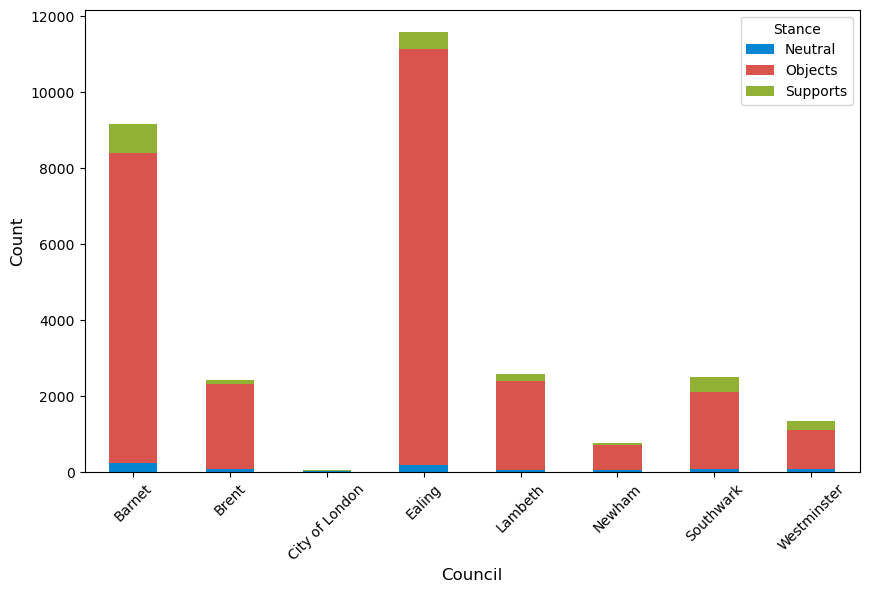

In [22]:
df_council_count.plot(
    x='Council',
    kind='bar',
    stacked=True,
    color={'Neutral': 'xkcd:cerulean', 'Objects': 'xkcd:pale red', 'Supports': 'xkcd:avocado'},
    figsize=(10, 6),
    # title='Comments Received by Council'
)
plt.xlabel('Council', fontsize=12)
plt.xticks(rotation=45)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Stance')
plt.show()

In [21]:
london_lad = gpd.read_file('../data/Local_Authority_Districts_May_2024_London.geojson')

In [22]:
london_lad

,lad_code,Area,longitude,latitude,geometry
0,E09000001,City of London,-0.093510,51.51564,"POLYGON ((533332.88 180406.812, 531312.428 180..."
1,E09000002,Barking and Dagenham,0.129479,51.54555,"POLYGON ((549992.037 181417.524, 549895.006 18..."
2,E09000003,Barnet,-0.218190,51.61107,"POLYGON ((525822.507 198220.521, 525566.689 19..."
3,E09000004,Bexley,0.146212,51.45822,"POLYGON ((550181.311 180645.759, 550636.429 18..."
4,E09000005,Brent,-0.275680,51.56438,"POLYGON ((523951.002 185545.75, 525529.383 183..."
5,E09000006,Bromley,0.039246,51.37266,"POLYGON ((544362.785 172374.32, 546620.254 170..."
6,E09000007,Camden,-0.162910,51.54305,"POLYGON ((528839.867 187215.913, 530323.717 18..."
7,E09000008,Croydon,-0.077610,51.36598,"POLYGON ((533699.518 170735.63, 534467.566 168..."
8,E09000009,Ealing,-0.314100,51.52442,"POLYGON ((521737.468 182993.864, 521351.837 17..."
9,E09000010,Enfield,-0.081440,51.64889,"POLYGON ((537543.809 199883.107, 537625.114 19..."


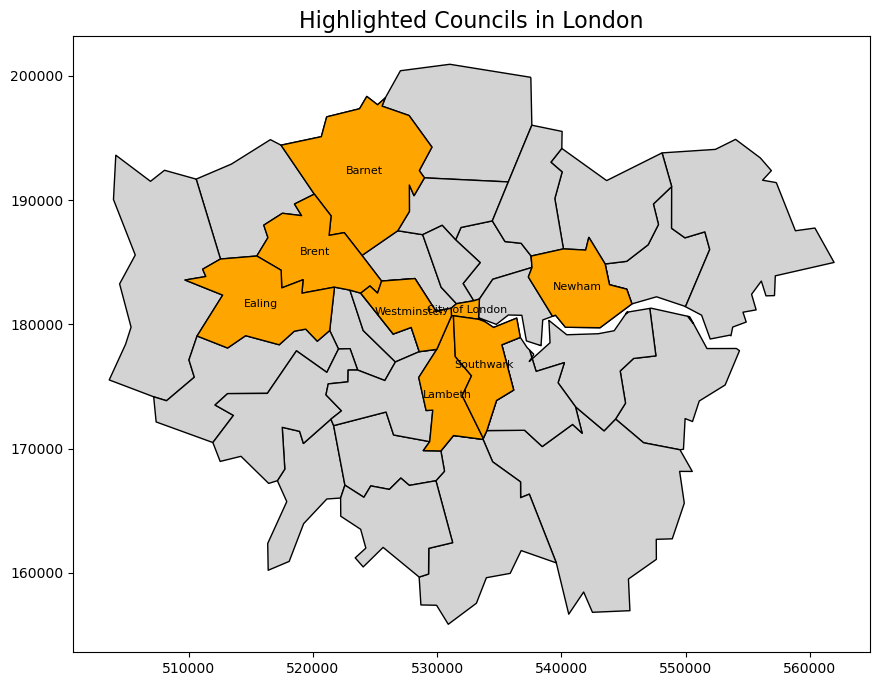

In [23]:
# Create a new column to indicate if the council is in the councils array
london_lad['highlight'] = london_lad['Area'].apply(lambda x: x in councils)

# Plot the GeoDataFrame
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
london_lad.plot(ax=ax, color='lightgrey', edgecolor='black')  # Default color for all areas
london_lad[london_lad['highlight']].plot(ax=ax, color='orange', edgecolor='black')  # Highlighted councils
# add council name for 'highlight'
for x, y, label in zip(london_lad.geometry.centroid.x, london_lad.geometry.centroid.y, london_lad['Area']):
    if label in councils:
        ax.text(x, y, label, fontsize=8, ha='center', va='center', color='black')

# Add title and legend
ax.set_title('Highlighted Councils in London', fontsize=16)
plt.show()